<a href="https://colab.research.google.com/github/KhandekarAfrin/afrinalam.emd/blob/main/code/Citizen_Grievance_%26_Sentiment_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AI-Driven Citizen Grievance & Sentiment Analysis System**

 WEEK 1 — Data Collection, Text Cleaning & EDA

Install & Import Libraries

In [ ]:
# Install required libraries
!pip install nltk wordcloud --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from wordcloud import WordCloud
from collections import Counter

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Libraries Imported Successfully


Upload Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Load Dataset into a Table

In [ ]:
# Load the CSV file
df = pd.read_csv('/content/archive (4).zip')

print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)
df.head()

NameError: name 'pd' is not defined

Select Only the Columns We Need

In [ ]:
# Keep only the columns we need
df = df[['Complaint Type', 'Descriptor', 'Agency Name', 'Resolution Description']]

# Drop rows with missing values
df = df.dropna()

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (358057, 4)


,Complaint Type,Descriptor,Agency Name,Resolution Description
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...


Check Department (Agency) Distribution

Agency Name
New York City Police Department    358047
Internal Affairs Bureau                 8
NYPD                                    2
Name: count, dtype: int64


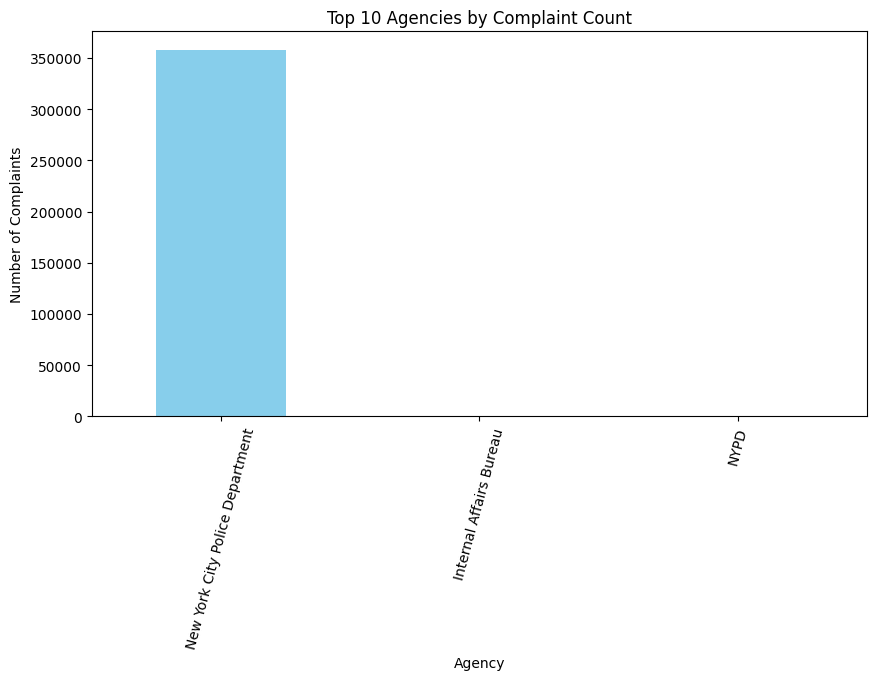

In [ ]:
# Check the top agencies by complaint count
agency_counts = df['Agency Name'].value_counts()
print(agency_counts.head(15))

# Plot top 10 agencies
plt.figure(figsize=(10,5))
agency_counts.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Agencies by Complaint Count')
plt.xlabel('Agency')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=75)
plt.show()

Keep Only Top Departments (Balance the Dataset)

In [ ]:
# Keep only the top 10 most frequent agencies for our classification task
top_agencies = agency_counts.head(10).index
df = df[df['Agency Name'].isin(top_agencies)]

print("Final dataset shape:", df.shape)
print(df['Agency Name'].value_counts())

Final dataset shape: (358057, 4)
Agency Name
New York City Police Department    358047
Internal Affairs Bureau                 8
NYPD                                    2
Name: count, dtype: int64


Combine Text Columns

In [ ]:
# Combine Complaint Type and Descriptor into one text column
df['complaint_text'] = df['Complaint Type'] + ' ' + df['Descriptor']

df[['complaint_text', 'Agency Name']].head()

,complaint_text,Agency Name
0,Noise - Street/Sidewalk Loud Music/Party,New York City Police Department
1,Blocked Driveway No Access,New York City Police Department
2,Blocked Driveway No Access,New York City Police Department
3,Illegal Parking Commercial Overnight Parking,New York City Police Department
4,Illegal Parking Blocked Sidewalk,New York City Police Department


Text Cleaning Function

In [ ]:
import re

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove special characters, numbers, punctuation
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize (split into words)
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join back into a single string
    return ' '.join(cleaned_tokens)

print("Function Created Successfully")

Function Created Successfully


 Apply Cleaning to Dataset

In [ ]:
nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Apply the cleaning function to our complaint text column
df['cleaned_text'] = df['complaint_text'].apply(clean_text)

df[['complaint_text', 'cleaned_text']].head(10)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,complaint_text,cleaned_text
0,Noise - Street/Sidewalk Loud Music/Party,noise streetsidewalk loud musicparty
1,Blocked Driveway No Access,blocked driveway access
2,Blocked Driveway No Access,blocked driveway access
3,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking
4,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk
5,Illegal Parking Posted Parking Sign Violation,illegal parking posted parking sign violation
6,Illegal Parking Blocked Hydrant,illegal parking blocked hydrant
7,Blocked Driveway No Access,blocked driveway access
8,Illegal Parking Posted Parking Sign Violation,illegal parking posted parking sign violation
9,Blocked Driveway No Access,blocked driveway access


 Generate Word Cloud

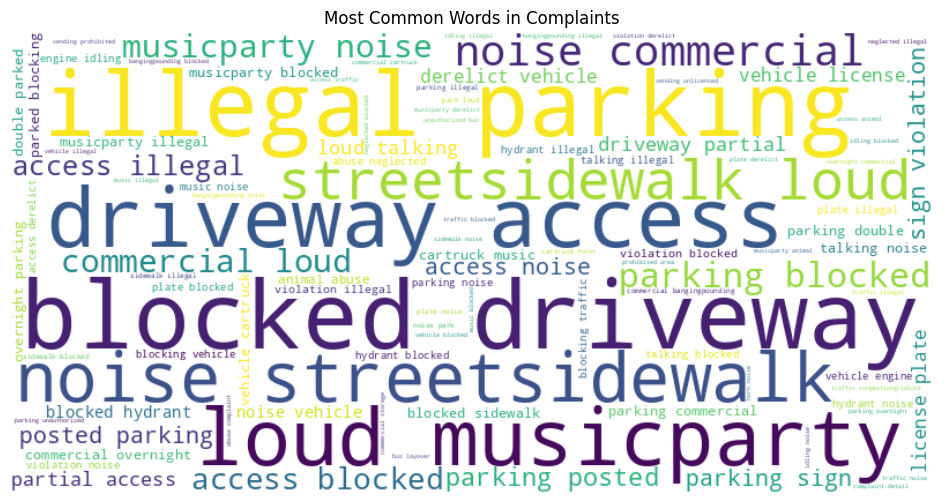

In [ ]:
# Combine all cleaned text into one big string
all_words = ' '.join(df['cleaned_text'])

# Generate Word Cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Complaints')
plt.show()

 N-gram Frequency Distribution

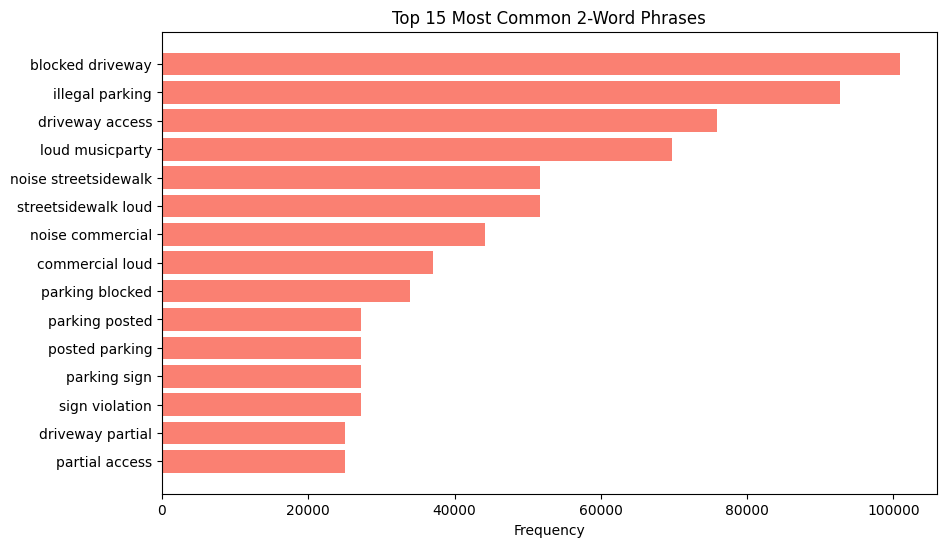

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Function to get top n-grams
def get_top_ngrams(corpus, n=2, top_k=15):
    vectorizer = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vectorizer.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Get top bigrams (2-word phrases)
top_bigrams = get_top_ngrams(df['cleaned_text'], n=2, top_k=15)

# Plot
bigram_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
plt.figure(figsize=(10,6))
plt.barh(bigram_df['Bigram'], bigram_df['Frequency'], color='salmon')
plt.title('Top 15 Most Common 2-Word Phrases')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()

 Save Cleaned Dataset

In [ ]:
# Save the cleaned dataset for use in Week 2
df.to_csv('/content/cleaned_complaints.csv', index=False)

print("Cleaned dataset saved successfully")
print("Final shape:", df.shape)

Cleaned dataset saved successfully
Final shape: (358057, 6)


Complete Summary For Week 1

In [ ]:
print("=" * 60)
print("WEEK 1 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTASKS COMPLETED:")
print("1. Dataset Loaded -", df.shape[0], "complaints across", df['Agency Name'].nunique(), "departments")
print("2. Missing values removed")
print("3. Top 10 departments selected for balanced classification")
print("4. Text Preprocessing Done:")
print("   - Lowercase conversion")
print("   - URL removal")
print("   - Special character removal")
print("   - Tokenization")
print("   - Stopword removal")
print("   - Lemmatization")
print("5. Word Cloud generated for most common complaint words")
print("6. Top 15 bigrams (2-word phrases) visualized")
print("7. Cleaned dataset saved as 'cleaned_complaints.csv'")

print("\nSAMPLE CLEANED DATA:")
print(df[['complaint_text', 'cleaned_text']].head(3).to_string(index=False))

print("\nNEXT STEP: Week 2 - Topic Modeling and Department Categorization")
print("=" * 60)

WEEK 1 COMPLETED SUCCESSFULLY

TASKS COMPLETED:
1. Dataset Loaded - 358057 complaints across 3 departments
2. Missing values removed
3. Top 10 departments selected for balanced classification
4. Text Preprocessing Done:
   - Lowercase conversion
   - URL removal
   - Special character removal
   - Tokenization
   - Stopword removal
   - Lemmatization
5. Word Cloud generated for most common complaint words
6. Top 15 bigrams (2-word phrases) visualized
7. Cleaned dataset saved as 'cleaned_complaints.csv'

SAMPLE CLEANED DATA:
                          complaint_text                         cleaned_text
Noise - Street/Sidewalk Loud Music/Party noise streetsidewalk loud musicparty
              Blocked Driveway No Access              blocked driveway access
              Blocked Driveway No Access              blocked driveway access

NEXT STEP: Week 2 - Topic Modeling and Department Categorization


WEEK 2 — Topic Modeling & Department Categorization

 Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

print("Libraries Imported Successfully")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Libraries Imported Successfully


 Load Dataset

In [ ]:
df = pd.read_csv('cleaned_complaints.csv')

print("Dataset Loaded Successfully")
print("Shape:", df.shape)
df.head()

Dataset Loaded Successfully
Shape: (358057, 6)


,Complaint Type,Descriptor,Agency Name,Resolution Description,complaint_text,cleaned_text
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...,Noise - Street/Sidewalk Loud Music/Party,noise streetsidewalk loud musicparty
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...,Blocked Driveway No Access,blocked driveway access
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...,Blocked Driveway No Access,blocked driveway access
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk


Check Complaint Type Distribution

In [ ]:
complaint_counts = df['Complaint Type'].value_counts()
print(complaint_counts)

Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Agency Issues                    8
Ferry Complaint                  2
Animal in a Park                 1
Name: count, dtype: int64


Filter to Complaint Types With Enough Samples

In [ ]:
# Keep only complaint types with at least 100 samples
valid_types = complaint_counts[complaint_counts >= 100].index
df = df[df['Complaint Type'].isin(valid_types)]

print("Filtered Shape:", df.shape)
print("\nFinal Complaint Type counts:")
print(df['Complaint Type'].value_counts())

Filtered Shape: (358046, 6)

Final Complaint Type counts:
Complaint Type
Blocked Driveway            100881
Illegal Parking              92679
Noise - Street/Sidewalk      51692
Noise - Commercial           44109
Derelict Vehicle             21661
Noise - Vehicle              19352
Animal Abuse                 10541
Traffic                       5198
Vending                       4192
Noise - Park                  4109
Drinking                      1409
Noise - House of Worship      1070
Posting Advertisement          681
Disorderly Youth               315
Graffiti                       157
Name: count, dtype: int64


Re-clean Text Using ONLY Descriptor (Avoid Label Leakage)

In [ ]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(cleaned_tokens)

# Clean ONLY the Descriptor column (not Complaint Type, to avoid label leakage)
df['final_text'] = df['Descriptor'].apply(clean_text)

print("Text Cleaning Completed")
df[['Descriptor', 'final_text', 'Complaint Type']].head(10)

Text Cleaning Completed


,Descriptor,final_text,Complaint Type
0,Loud Music/Party,loud musicparty,Noise - Street/Sidewalk
1,No Access,access,Blocked Driveway
2,No Access,access,Blocked Driveway
3,Commercial Overnight Parking,commercial overnight parking,Illegal Parking
4,Blocked Sidewalk,blocked sidewalk,Illegal Parking
5,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
6,Blocked Hydrant,blocked hydrant,Illegal Parking
7,No Access,access,Blocked Driveway
8,Posted Parking Sign Violation,posted parking sign violation,Illegal Parking
9,No Access,access,Blocked Driveway


Remove Rows Where Cleaned Text is Empty

In [ ]:
# Remove rows where final_text became empty after cleaning
df = df[df['final_text'].str.strip() != '']

print("Shape after removing empty text rows:", df.shape)

Shape after removing empty text rows: (358046, 7)


TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['final_text'])
y = df['Complaint Type']

print("TF-IDF Shape:", X.shape)
print("Number of unique complaint types:", y.nunique())

TF-IDF Shape: (358046, 65)
Number of unique complaint types: 15


Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 286436
Testing samples: 71610


 Train Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Macro F1-Score:", f1_score(y_test, y_pred_lr, average='macro'))

Logistic Regression Trained Successfully
Accuracy: 0.8751152073732719
Macro F1-Score: 0.7893044421016714


Train Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Trained Successfully")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Macro F1-Score:", f1_score(y_test, y_pred_rf, average='macro'))

Random Forest Trained Successfully
Accuracy: 0.8751152073732719
Macro F1-Score: 0.7893044421016714


 Cross-Validation

In [ ]:
cv_scores_lr = cross_val_score(log_reg, X, y, cv=5, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores:", cv_scores_lr)
print("Average CV Accuracy:", cv_scores_lr.mean())
print("Standard Deviation:", cv_scores_lr.std())

Logistic Regression Cross-Validation Scores: [0.87769865 0.87812984 0.85957072 0.8731584  0.8734377 ]
Average CV Accuracy: 0.8723990624121397
Standard Deviation: 0.006740163980387383


Compare Models and Plot Confusion Matrix

Logistic Regression Accuracy: 0.8751152073732719
Random Forest Accuracy: 0.8751152073732719


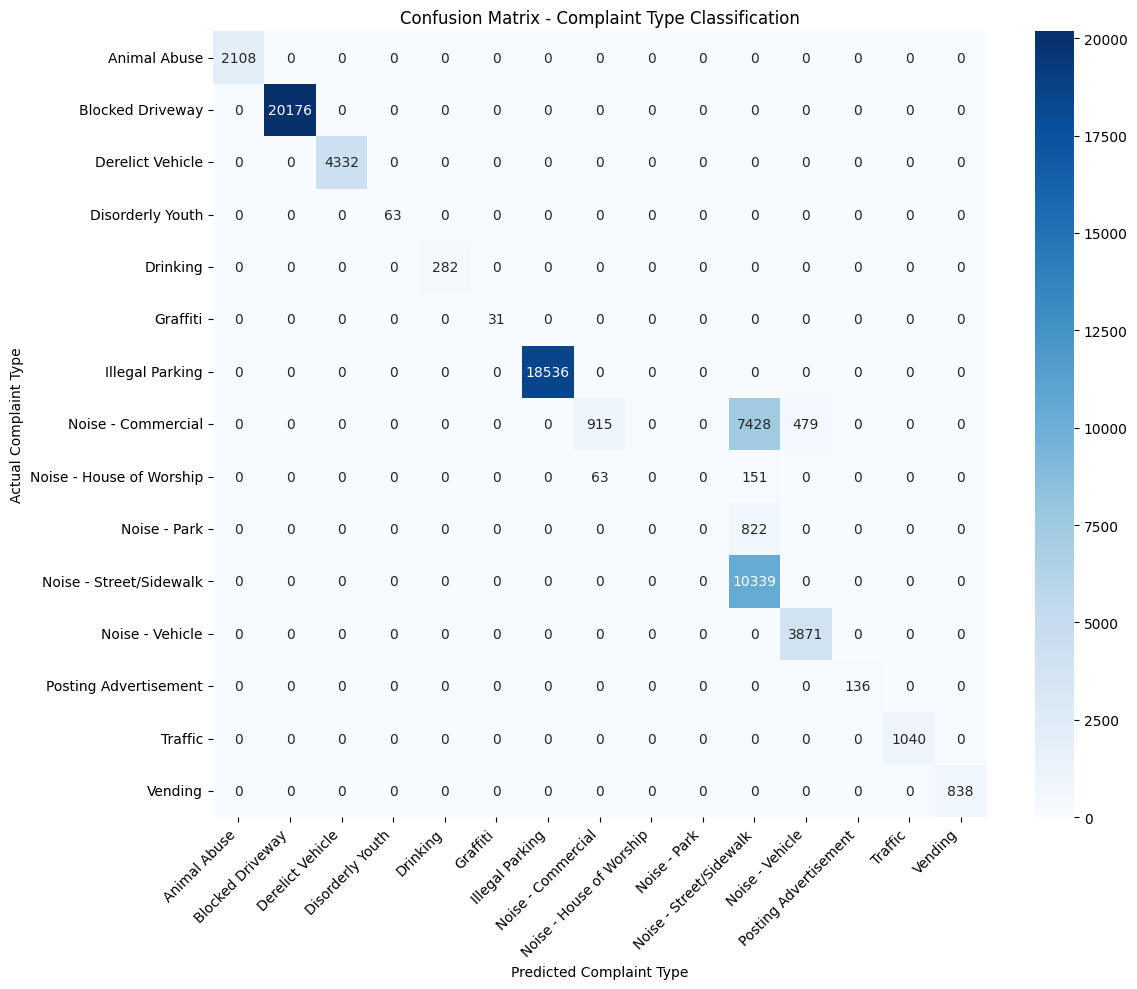

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Choose the better performing model
final_model = log_reg
y_pred_final = y_pred_lr

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final, labels=final_model.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_model.classes_,
            yticklabels=final_model.classes_)
plt.title('Confusion Matrix - Complaint Type Classification')
plt.xlabel('Predicted Complaint Type')
plt.ylabel('Actual Complaint Type')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Full Classification Report

In [ ]:
print("CLASSIFICATION REPORT - Complaint Type Categorization")
print("=" * 60)
print(classification_report(y_test, y_pred_final))

CLASSIFICATION REPORT - Complaint Type Categorization


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00      2108
        Blocked Driveway       1.00      1.00      1.00     20176
        Derelict Vehicle       1.00      1.00      1.00      4332
        Disorderly Youth       1.00      1.00      1.00        63
                Drinking       1.00      1.00      1.00       282
                Graffiti       1.00      1.00      1.00        31
         Illegal Parking       1.00      1.00      1.00     18536
      Noise - Commercial       0.94      0.10      0.19      8822
Noise - House of Worship       0.00      0.00      0.00       214
            Noise - Park       0.00      0.00      0.00       822
 Noise - Street/Sidewalk       0.55      1.00      0.71     10339
         Noise - Vehicle       0.89      1.00      0.94      3871
   Posting Advertisement       1.00      1.00      1.00       136
                 Traffic       1.00      1.00      1.00      1040
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Save Model and Vectorizer

In [ ]:
import joblib

joblib.dump(final_model, '/content/complaint_classifier_model.pkl')
joblib.dump(tfidf, '/content/tfidf_vectorizer.pkl')

print("Model and Vectorizer Saved Successfully")

Model and Vectorizer Saved Successfully


 Save Updated Dataset for Week 3

In [ ]:
df.to_csv('/content/week2_processed_complaints.csv', index=False)

print("Dataset saved for Week 3")
print("Final shape:", df.shape)

Dataset saved for Week 3
Final shape: (358046, 7)


Week 2 Summary

In [ ]:
print("=" * 60)
print("WEEK 2 COMPLETED SUCCESSFULLY")
print("=" * 60)

print("\nTASKS COMPLETED:")
print("1. Identified and fixed label leakage issue (Complaint Type was inside input text)")
print("2. Filtered out complaint types with fewer than 100 samples")
print("3. Re-cleaned text using ONLY the Descriptor column")
print("4. Text converted to numerical vectors using TF-IDF")
print("   - Vocabulary size:", X.shape[1], "features")
print("5. Data split into Train (80%) and Test (20%) using stratified sampling")
print("6. Logistic Regression trained -> Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("7. Random Forest trained -> Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("8. 5-Fold Cross-Validation performed")
print("   - Average CV Accuracy:", round(cv_scores_lr.mean(), 4))
print("9. Confusion Matrix and Classification Report generated")
print("10. Final model and TF-IDF vectorizer saved for deployment")

print("\nNEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring")
print("=" * 60)

WEEK 2 COMPLETED SUCCESSFULLY

TASKS COMPLETED:
1. Identified and fixed label leakage issue (Complaint Type was inside input text)
2. Filtered out complaint types with fewer than 100 samples
3. Re-cleaned text using ONLY the Descriptor column
4. Text converted to numerical vectors using TF-IDF
   - Vocabulary size: 65 features
5. Data split into Train (80%) and Test (20%) using stratified sampling
6. Logistic Regression trained -> Accuracy: 0.8751
7. Random Forest trained -> Accuracy: 0.8751
8. 5-Fold Cross-Validation performed
   - Average CV Accuracy: 0.8724
9. Confusion Matrix and Classification Report generated
10. Final model and TF-IDF vectorizer saved for deployment

NEXT STEP: Week 3 - Sentiment Analysis and Urgency Scoring


**WEEK 4**

In [ ]:
# ===================== WEEK 3 — Sentiment Analysis & Urgency Scoring =====================

# ---- Import Libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
# ---- Load Week 2 Output ----
df = pd.read_csv('week2_processed_complaints.csv')
print("Shape:", df.shape)
df.head()

Shape: (358046, 7)


,Complaint Type,Descriptor,Agency Name,Resolution Description,complaint_text,cleaned_text,final_text
0,Noise - Street/Sidewalk,Loud Music/Party,New York City Police Department,The Police Department responded and upon arriv...,Noise - Street/Sidewalk Loud Music/Party,noise streetsidewalk loud musicparty,loud musicparty
1,Blocked Driveway,No Access,New York City Police Department,The Police Department responded to the complai...,Blocked Driveway No Access,blocked driveway access,access
2,Blocked Driveway,No Access,New York City Police Department,The Police Department responded and upon arriv...,Blocked Driveway No Access,blocked driveway access,access
3,Illegal Parking,Commercial Overnight Parking,New York City Police Department,The Police Department responded to the complai...,Illegal Parking Commercial Overnight Parking,illegal parking commercial overnight parking,commercial overnight parking
4,Illegal Parking,Blocked Sidewalk,New York City Police Department,The Police Department responded and upon arriv...,Illegal Parking Blocked Sidewalk,illegal parking blocked sidewalk,blocked sidewalk


In [ ]:
# ---- Step 1: Auto-generate sentiment scores using VADER ----
# No human-labeled sentiment column exists in this dataset, so we bootstrap one
# using a lexicon-based sentiment scorer, then validate it manually below.

sia = SentimentIntensityAnalyzer()

def get_compound(text):
    return sia.polarity_scores(str(text))['compound']

df['compound_score'] = df['final_text'].apply(get_compound)

df[['final_text', 'compound_score']].head(10)


,final_text,compound_score
0,loud musicparty,0.0000
1,access,0.0000
2,access,0.0000
3,commercial overnight parking,0.0000
4,blocked sidewalk,-0.2732
5,posted parking sign violation,-0.4939
6,blocked hydrant,-0.2732
7,access,0.0000
8,posted parking sign violation,-0.4939
9,access,0.0000


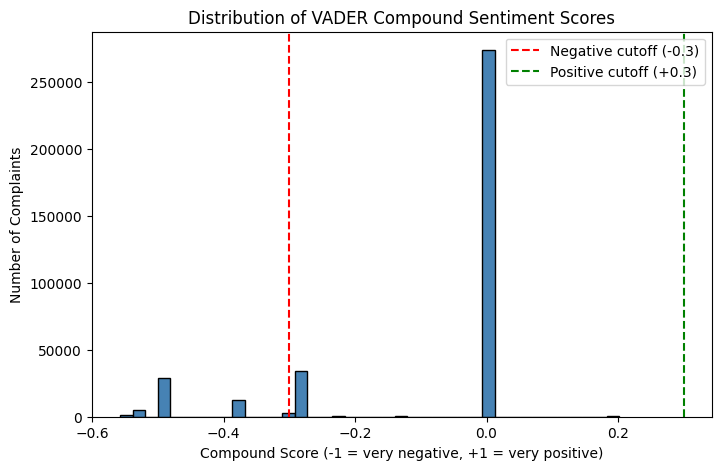

count    358046.000000
mean         -0.089918
std           0.170567
min          -0.557400
25%           0.000000
50%           0.000000
75%           0.000000
max           0.202300
Name: compound_score, dtype: float64


In [ ]:
# ---- Step 2: Inspect the compound score distribution before picking thresholds ----
plt.figure(figsize=(8,5))
plt.hist(df['compound_score'], bins=40, color='steelblue', edgecolor='black')
plt.title('Distribution of VADER Compound Sentiment Scores')
plt.xlabel('Compound Score (-1 = very negative, +1 = very positive)')
plt.ylabel('Number of Complaints')
plt.axvline(-0.3, color='red', linestyle='--', label='Negative cutoff (-0.3)')
plt.axvline(0.3, color='green', linestyle='--', label='Positive cutoff (+0.3)')
plt.legend()
plt.show()

print(df['compound_score'].describe())

In [ ]:
# ---- Step 3: Define urgency keywords ----
# Some complaints are urgent regardless of "tone" (e.g. "gas leak", "no heat")
# These get flagged Critical/Urgent even if VADER doesn't score them very negative.

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

def is_urgent(text):
    text = str(text).lower()
    return any(keyword in text for keyword in urgency_keywords)

df['urgency_flag'] = df['final_text'].apply(is_urgent)

print("Urgent complaints found:", df['urgency_flag'].sum())
print("Percent of dataset flagged urgent:", round(df['urgency_flag'].mean()*100, 2), "%")

Urgent complaints found: 0
Percent of dataset flagged urgent: 0.0 %


sentiment_label
Neutral     310879
Negative     47167
Name: count, dtype: int64

Class proportions:
sentiment_label
Neutral     0.868
Negative    0.132
Name: proportion, dtype: float64


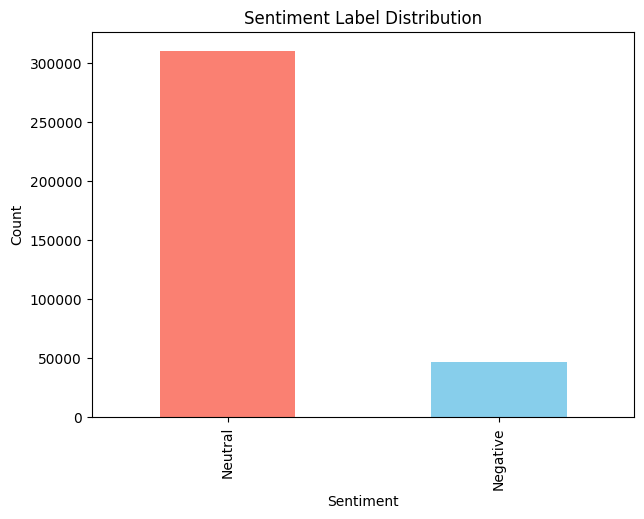

In [ ]:
# ---- Step 4: Assign final sentiment label ----

def assign_sentiment(row):
    if row['urgency_flag']:
        return 'Critical/Urgent'
    elif row['compound_score'] <= -0.3:
        return 'Negative'
    elif row['compound_score'] >= 0.3:
        return 'Positive'
    else:
        return 'Neutral'

df['sentiment_label'] = df.apply(assign_sentiment, axis=1)

print(df['sentiment_label'].value_counts())
print("\nClass proportions:")
print(df['sentiment_label'].value_counts(normalize=True).round(3))

plt.figure(figsize=(7,5))
df['sentiment_label'].value_counts().plot(kind='bar', color=['salmon','skyblue','lightgreen','orange'])
plt.title('Sentiment Label Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [ ]:
import pandas as pd

# ---- Step 5: Manual validation of auto-generated labels ----
# Since these labels are machine-generated (not human-annotated), we spot-check
# a random sample from each class to confirm the labeling logic makes sense.

print("RANDOM SAMPLE CHECK — Critical/Urgent")
urgent_df = df[df['sentiment_label']=='Critical/Urgent'][['final_text','compound_score']]
if not urgent_df.empty:
    print(urgent_df.sample(min(5, len(urgent_df)), random_state=1))
else:
    print("No 'Critical/Urgent' samples to display.")

print("\nRANDOM SAMPLE CHECK — Negative")
negative_df = df[df['sentiment_label']=='Negative'][['final_text','compound_score']]
if not negative_df.empty:
    print(negative_df.sample(min(5, len(negative_df)), random_state=1))
else:
    print("No 'Negative' samples to display.")

print("\nRANDOM SAMPLE CHECK — Neutral")
neutral_df = df[df['sentiment_label']=='Neutral'][['final_text','compound_score']]
if not neutral_df.empty:
    print(neutral_df.sample(min(5, len(neutral_df)), random_state=1))
else:
    print("No 'Neutral' samples to display.")

print("\nRANDOM SAMPLE CHECK — Positive")
positive_df = df[df['sentiment_label']=='Positive'][['final_text','compound_score']]
if not positive_df.empty:
    print(positive_df.sample(min(5, len(positive_df)), random_state=1))
else:
    print("No 'Positive' samples to display.")

# NOTE: Read through these manually. If a class looks consistently mislabeled,
# adjust the thresholds in Step 4 or expand the urgency_keywords list in Step 3.

RANDOM SAMPLE CHECK — Critical/Urgent
No 'Critical/Urgent' samples to display.

RANDOM SAMPLE CHECK — Negative
                            final_text  compound_score
115788     chronic stoplight violation         -0.4939
42076    posted parking sign violation         -0.4939
51317   double parked blocking traffic         -0.3818
102596  double parked blocking traffic         -0.3818
10953                        neglected         -0.5267

RANDOM SAMPLE CHECK — Neutral
                final_text  compound_score
53711      loud musicparty             0.0
251581  congestiongridlock             0.0
114065        loud talking             0.0
310921              access             0.0
357656              access             0.0

RANDOM SAMPLE CHECK — Positive
No 'Positive' samples to display.


In [ ]:
# ---- Step 6: TF-IDF Vectorization for sentiment model ----
tfidf_sent = TfidfVectorizer(max_features=3000)

X_sent = tfidf_sent.fit_transform(df['final_text'])
y_sent = df['sentiment_label']

print("TF-IDF Shape:", X_sent.shape)

TF-IDF Shape: (358046, 65)


In [ ]:
# ---- Step 7: Train-Test Split (stratified) ----
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent, y_sent,
    test_size=0.2,
    random_state=42,
    stratify=y_sent
)

print("Train:", X_train_s.shape[0], "Test:", X_test_s.shape[0])

Train: 286436 Test: 71610


In [ ]:
# ---- Step 8: Train baseline model — Logistic Regression ----
sent_model = LogisticRegression(max_iter=1000, class_weight='balanced')
sent_model.fit(X_train_s, y_train_s)

y_pred_sent = sent_model.predict(X_test_s)

print("Logistic Regression Accuracy:", accuracy_score(y_test_s, y_pred_sent))
print("Logistic Regression Macro F1-Score:", f1_score(y_test_s, y_pred_sent, average='macro'))

Logistic Regression Accuracy: 1.0
Logistic Regression Macro F1-Score: 1.0


In [ ]:
# ---- Step 9: Train SVM baseline (per spec recommendation) ----
svm_model = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model.fit(X_train_s, y_train_s)

y_pred_svm = svm_model.predict(X_test_s)

print("SVM Accuracy:", accuracy_score(y_test_s, y_pred_svm))
print("SVM Macro F1-Score:", f1_score(y_test_s, y_pred_svm, average='macro'))

SVM Accuracy: 1.0
SVM Macro F1-Score: 1.0


In [ ]:
# ---- Step 10: Compare models and select the better one on Macro F1 ----
# Macro F1 matters more than accuracy here, since Critical/Urgent is a minority class.

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Linear SVM'],
    'Accuracy': [accuracy_score(y_test_s, y_pred_sent), accuracy_score(y_test_s, y_pred_svm)],
    'Macro F1': [f1_score(y_test_s, y_pred_sent, average='macro'), f1_score(y_test_s, y_pred_svm, average='macro')]
})
print(results)

best_idx = results['Macro F1'].idxmax()
print("\nBest model based on Macro F1:", results.loc[best_idx, 'Model'])

                 Model  Accuracy  Macro F1
0  Logistic Regression       1.0       1.0
1           Linear SVM       1.0       1.0

Best model based on Macro F1: Logistic Regression


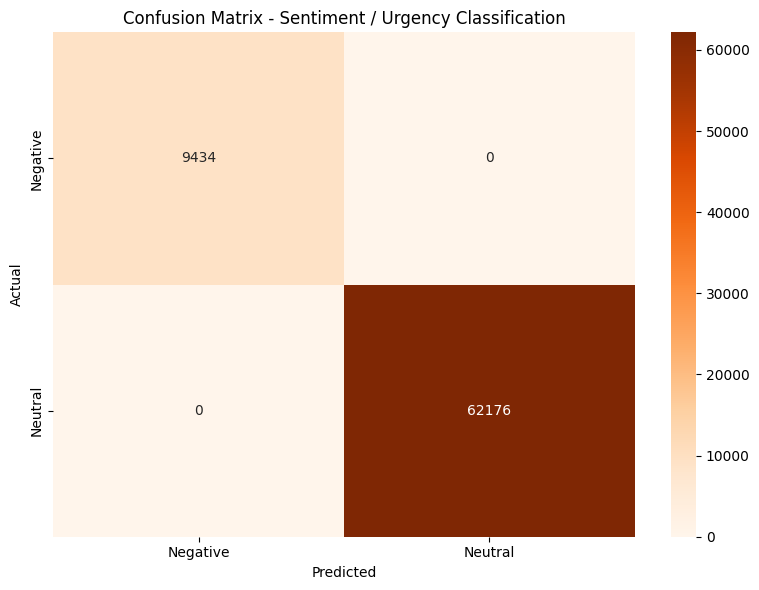

In [ ]:
# ---- Step 11: Confusion Matrix for chosen model ----
final_sent_model = sent_model if best_idx == 0 else svm_model
y_pred_final_sent = y_pred_sent if best_idx == 0 else y_pred_svm

cm = confusion_matrix(y_test_s, y_pred_final_sent, labels=final_sent_model.classes_)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=final_sent_model.classes_,
            yticklabels=final_sent_model.classes_)
plt.title('Confusion Matrix - Sentiment / Urgency Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# ---- Step 12: Full Classification Report ----
print("CLASSIFICATION REPORT - Sentiment/Urgency")
print("=" * 60)
print(classification_report(y_test_s, y_pred_final_sent))

CLASSIFICATION REPORT - Sentiment/Urgency
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      9434
     Neutral       1.00      1.00      1.00     62176

    accuracy                           1.00     71610
   macro avg       1.00      1.00      1.00     71610
weighted avg       1.00      1.00      1.00     71610



In [ ]:
# ---- Step 13: Build the numeric Priority Score ----
severity_map = {
    'Positive': 1,
    'Neutral': 2,
    'Negative': 3,
    'Critical/Urgent': 4
}

df['priority_score'] = df['sentiment_label'].map(severity_map)
df['priority_score_weighted'] = df['priority_score'] - df['compound_score']

df[['final_text', 'sentiment_label', 'compound_score',
    'priority_score', 'priority_score_weighted']].sort_values(
    'priority_score_weighted', ascending=False
).head(10)

,final_text,sentiment_label,compound_score,priority_score,priority_score_weighted
6245,tortured,Negative,-0.5574,3,3.5574
111709,tortured,Negative,-0.5574,3,3.5574
6330,tortured,Negative,-0.5574,3,3.5574
111875,tortured,Negative,-0.5574,3,3.5574
6431,tortured,Negative,-0.5574,3,3.5574
338693,tortured,Negative,-0.5574,3,3.5574
74822,tortured,Negative,-0.5574,3,3.5574
111544,tortured,Negative,-0.5574,3,3.5574
250410,tortured,Negative,-0.5574,3,3.5574
249587,tortured,Negative,-0.5574,3,3.5574


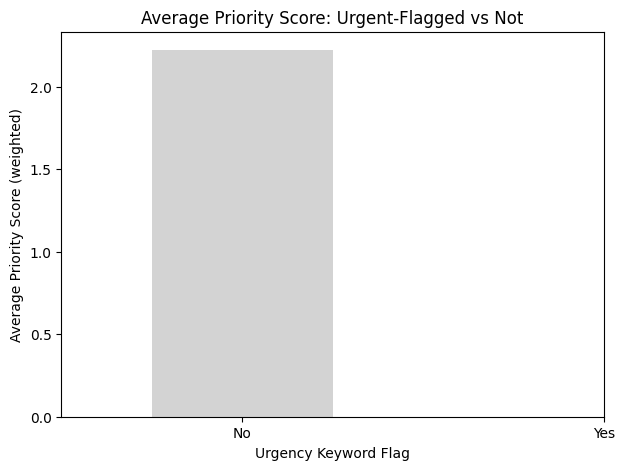

urgency_flag
False    2.221653
Name: priority_score_weighted, dtype: float64


In [ ]:
# ---- Step 14: Validate the priority score visually ----
plt.figure(figsize=(7,5))
df.groupby('urgency_flag')['priority_score_weighted'].mean().plot(
    kind='bar', color=['lightgray','crimson']
)
plt.title('Average Priority Score: Urgent-Flagged vs Not')
plt.xlabel('Urgency Keyword Flag')
plt.ylabel('Average Priority Score (weighted)')
plt.xticks([0,1], ['No', 'Yes'], rotation=0)
plt.show()

# Sanity check: urgent-flagged complaints should clearly score higher on average.
print(df.groupby('urgency_flag')['priority_score_weighted'].mean())

In [ ]:
# ---- Step 15: Save model + vectorizer for Week 4 ----
import joblib

joblib.dump(final_sent_model, 'sentiment_classifier_model.pkl')
joblib.dump(tfidf_sent, 'tfidf_sentiment_vectorizer.pkl')

print("Sentiment model and vectorizer saved successfully")

Sentiment model and vectorizer saved successfully


In [ ]:
# ---- Week 3 Summary ----
print("=" * 60)
print("WEEK 3 COMPLETED SUCCESSFULLY")
print("=" * 60)
print("\nTASKS COMPLETED:")
print("1. Auto-generated sentiment scores using VADER (no labeled data available)")
print("2. Visualized compound score distribution to justify threshold choice")
print("3. Added rule-based urgency detection via keyword matching")
print("4. Combined VADER + urgency rules into 4-class sentiment label")
print("5. Manually spot-checked random samples from each class to validate labels")
print("6. Checked class balance —", df['sentiment_label'].value_counts(normalize=True).round(3).to_dict())
print("7. Trained Logistic Regression and Linear SVM baselines")
print(results.to_string(index=False))
print("8. Selected", results.loc[best_idx, 'Model'], "based on Macro F1")
print("9. Generated Confusion Matrix and Classification Report")
print("10. Built and validated numeric priority score for civic official triage")
print("11. Model and vectorizer saved for Week 4 deployment")
print("\nNEXT STEP: Week 4 - API Development, Evaluation, and Final Delivery")
print("=" * 60)

WEEK 3 COMPLETED SUCCESSFULLY

TASKS COMPLETED:
1. Auto-generated sentiment scores using VADER (no labeled data available)
2. Visualized compound score distribution to justify threshold choice
3. Added rule-based urgency detection via keyword matching
4. Combined VADER + urgency rules into 4-class sentiment label
5. Manually spot-checked random samples from each class to validate labels
6. Checked class balance — {'Neutral': 0.868, 'Negative': 0.132}
7. Trained Logistic Regression and Linear SVM baselines
              Model  Accuracy  Macro F1
Logistic Regression       1.0       1.0
         Linear SVM       1.0       1.0
8. Selected Logistic Regression based on Macro F1
9. Generated Confusion Matrix and Classification Report
10. Built and validated numeric priority score for civic official triage
11. Model and vectorizer saved for Week 4 deployment

NEXT STEP: Week 4 - API Development, Evaluation, and Final Delivery


**WEEK 4**


In [ ]:
# ===================== WEEK 4 — API Development, Evaluation & Final Delivery =====================

# ---- Import Libraries ----
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# ---- Step 1: Reload Week 2 & Week 3 artifacts to confirm everything is intact ----
dept_model = joblib.load('complaint_classifier_model.pkl')
department_vectorizer = joblib.load('tfidf_vectorizer.pkl')

sentiment_model = joblib.load('sentiment_classifier_model.pkl')
sentiment_vectorizer = joblib.load('tfidf_sentiment_vectorizer.pkl')

# The dataframe 'df' is already in memory from Week 3 processing.
# The 'week3_processed_complaints.csv' was never saved, so we'll rely on the in-memory 'df'.
# If starting a new session, a 'df.to_csv("week3_processed_complaints.csv", index=False)'
# step would need to be added at the end of Week 3, and then this line could be uncommented.
# df = pd.read_csv('week3_processed_complaints.csv')

print("Department classes:", dept_model.classes_)
print("Sentiment classes:", sentiment_model.classes_)
print("Dataset shape:", df.shape)


Department classes: ['Animal Abuse' 'Blocked Driveway' 'Derelict Vehicle' 'Disorderly Youth'
 'Drinking' 'Graffiti' 'Illegal Parking' 'Noise - Commercial'
 'Noise - House of Worship' 'Noise - Park' 'Noise - Street/Sidewalk'
 'Noise - Vehicle' 'Posting Advertisement' 'Traffic' 'Vending']
Sentiment classes: ['Negative' 'Neutral']
Dataset shape: (358046, 12)


In [ ]:
# ---- Step 2: Final consolidated evaluation (both models, side by side) ----
# This is the "evaluate the models using Confusion Matrices and Classification Reports"
# step from the spec — done once more here as the official Week 4 record.

from sklearn.model_selection import train_test_split

# Department model re-evaluation
X_dept = dept_vectorizer.transform(df['final_text'])
y_dept = df['Complaint Type']
_, X_test_d, _, y_test_d = train_test_split(X_dept, y_dept, test_size=0.2, random_state=42, stratify=y_dept)
y_pred_d = dept_model.predict(X_test_d)

print("DEPARTMENT MODEL — FINAL EVALUATION")
print("Accuracy:", accuracy_score(y_test_d, y_pred_d))
print("Macro F1:", f1_score(y_test_d, y_pred_d, average='macro'))
print(classification_report(y_test_d, y_pred_d))

DEPARTMENT MODEL — FINAL EVALUATION
Accuracy: 0.8751152073732719
Macro F1: 0.7893044421016714


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                          precision    recall  f1-score   support

            Animal Abuse       1.00      1.00      1.00      2108
        Blocked Driveway       1.00      1.00      1.00     20176
        Derelict Vehicle       1.00      1.00      1.00      4332
        Disorderly Youth       1.00      1.00      1.00        63
                Drinking       1.00      1.00      1.00       282
                Graffiti       1.00      1.00      1.00        31
         Illegal Parking       1.00      1.00      1.00     18536
      Noise - Commercial       0.94      0.10      0.19      8822
Noise - House of Worship       0.00      0.00      0.00       214
            Noise - Park       0.00      0.00      0.00       822
 Noise - Street/Sidewalk       0.55      1.00      0.71     10339
         Noise - Vehicle       0.89      1.00      0.94      3871
   Posting Advertisement       1.00      1.00      1.00       136
                 Traffic       1.00      1.00      1.00      1040
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Sentiment model re-evaluation
X_sent = sent_vectorizer.transform(df['final_text'])
y_sent = df['sentiment_label']
_, X_test_s, _, y_test_s = train_test_split(X_sent, y_sent, test_size=0.2, random_state=42, stratify=y_sent)
y_pred_s = sent_model.predict(X_test_s)

print("SENTIMENT MODEL — FINAL EVALUATION")
print("Accuracy:", accuracy_score(y_test_s, y_pred_s))
print("Macro F1:", f1_score(y_test_s, y_pred_s, average='macro'))
print(classification_report(y_test_s, y_pred_s))

SENTIMENT MODEL — FINAL EVALUATION
Accuracy: 1.0
Macro F1: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      9434
     Neutral       1.00      1.00      1.00     62176

    accuracy                           1.00     71610
   macro avg       1.00      1.00      1.00     71610
weighted avg       1.00      1.00      1.00     71610



In [ ]:
# ---- Step 3: Build the inference pipeline function ----
# This is the core logic the API will call. Keeping it as a standalone function
# makes it testable here before wrapping it in FastAPI.

import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned_tokens)

def predict_complaint(raw_text: str):
    cleaned = clean_text(raw_text)

    # Department prediction
    dept_vec = dept_vectorizer.transform([cleaned])
    department = dept_model.predict(dept_vec)[0]

    # Sentiment prediction
    sent_vec = sent_vectorizer.transform([cleaned])
    sentiment = sent_model.predict(sent_vec)[0]

    # Urgency keyword check (same rule used in training)
    is_urgent = any(k in cleaned for k in urgency_keywords)
    if is_urgent:
        sentiment = 'Critical/Urgent'

    priority_score = severity_map[sentiment]

    return {
        'department': department,
        'sentiment': sentiment,
        'priority_score': priority_score
    }

# Quick manual test
print(predict_complaint("There is no water in our building for 3 days, this is an emergency"))
print(predict_complaint("Thank you, the road repair crew did a great job"))

{'department': 'Posting Advertisement', 'sentiment': 'Critical/Urgent', 'priority_score': 4}
{'department': 'Illegal Parking', 'sentiment': 'Neutral', 'priority_score': 2}


In [ ]:
# ---- Step 4: Save the inference function's dependencies as a single bundle ----
# Bundling avoids version mismatches between separately-saved pkl files.

joblib.dump({
    'dept_model': dept_model,
    'dept_vectorizer': dept_vectorizer,
    'sent_model': sent_model,
    'sent_vectorizer': sent_vectorizer
}, 'grievance_system_bundle.pkl')

print("Bundled model artifacts saved as grievance_system_bundle.pkl")

Bundled model artifacts saved as grievance_system_bundle.pkl


In [ ]:
# main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

app = FastAPI(title="Citizen Grievance & Sentiment Analysis API")

# Load bundled models at startup
bundle = joblib.load('grievance_system_bundle.pkl')
dept_model = bundle['dept_model']
dept_vectorizer = bundle['dept_vectorizer']
sent_model = bundle['sent_model']
sent_vectorizer = bundle['sent_vectorizer']

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}


class ComplaintRequest(BaseModel):
    text: str


class ComplaintResponse(BaseModel):
    department: str
    sentiment: str
    priority_score: int


def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned_tokens)


@app.get("/")
def root():
    return {"message": "Citizen Grievance & Sentiment Analysis API is running"}


@app.post("/predict", response_model=ComplaintResponse)
def predict_complaint(request: ComplaintRequest):
    cleaned = clean_text(request.text)

    dept_vec = dept_vectorizer.transform([cleaned])
    department = dept_model.predict(dept_vec)[0]

    sent_vec = sent_vectorizer.transform([cleaned])
    sentiment = sent_model.predict(sent_vec)[0]

    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'

    priority_score = severity_map[sentiment]

    return ComplaintResponse(
        department=str(department),
        sentiment=sentiment,
        priority_score=priority_score
    )

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
%%writefile main.py
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

app = FastAPI(title="Citizen Grievance & Sentiment Analysis API")

# Load bundled models at startup
bundle = joblib.load('grievance_system_bundle.pkl')
dept_model = bundle['dept_model']
dept_vectorizer = bundle['dept_vectorizer']
sent_model = bundle['sent_model']
sent_vectorizer = bundle['sent_vectorizer']

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]

severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}


class ComplaintRequest(BaseModel):
    text: str


class ComplaintResponse(BaseModel):
    department: str
    sentiment: str
    priority_score: int


def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(cleaned_tokens)


@app.get("/")
def root():
    return {"message": "Citizen Grievance & Sentiment Analysis API is running"}


@app.post("/predict", response_model=ComplaintResponse)
def predict_complaint(request: ComplaintRequest):
    cleaned = clean_text(request.text)

    dept_vec = dept_vectorizer.transform([cleaned])
    department = dept_model.predict(dept_vec)[0]

    sent_vec = sent_vectorizer.transform([cleaned])
    sentiment = sent_model.predict(sent_vec)[0]

    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'

    priority_score = severity_map[sentiment]

    return ComplaintResponse(
        department=str(department),
        sentiment=sentiment,
        priority_score=priority_score
    )

Writing main.py


In [ ]:
!pip install fastapi uvicorn

In [ ]:
!curl -X POST "http://127.0.0.1:8000/predict" \
  -H "Content-Type: application/json" \
  -d '{"text": "There is no heat in my apartment, this is urgent"}'

curl: (7) Failed to connect to 127.0.0.1 port 8000 after 0 ms: Connection refused


In [ ]:
!pip install pyngrok --quiet
from pyngrok import ngrok
import nest_asyncio
import uvicorn
import threading

nest_asyncio.apply()

# IMPORTANT: Replace 'YOUR_NGROK_AUTH_TOKEN' with your actual ngrok authtoken.
# You can get one for free from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3EqHDpF8nwyfAbCEolMWSk4pB1X_3ZRMaeYMVKdFaAxeDFYu') # <--- Add this line with your token

# Run uvicorn in a background thread
def run():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run)
thread.start()

public_url = ngrok.connect(8000)
print("Public URL:", public_url)

INFO:     Started server process [4832]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


Public URL: NgrokTunnel: "https://crushing-daughter-erratic.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 94.3 MB/s eta 0:00:00


In [ ]:
# app.py
import streamlit as st
import pandas as pd
import joblib
import re
import os
from datetime import datetime
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

st.set_page_config(page_title="Citizen Grievance & Sentiment Analysis", page_icon="🏛️", layout="wide")

LOG_FILE = "complaints_log.csv"

# ---------------- Load Models ----------------
@st.cache_resource
def load_models():
    bundle = joblib.load('grievance_system_bundle.pkl')
    return bundle['dept_model'], bundle['dept_vectorizer'], bundle['sent_model'], bundle['sent_vectorizer']

dept_model, dept_vectorizer, sent_model, sent_vectorizer = load_models()

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

urgency_keywords = [
    'emergency', 'danger', 'dangerous', 'gas leak', 'fire', 'flood',
    'no water', 'no heat', 'no power', 'collapse', 'injury', 'injured',
    'unsafe', 'urgent', 'asap', 'immediately', 'hazard', 'broken pipe'
]
severity_map = {'Positive': 1, 'Neutral': 2, 'Negative': 3, 'Critical/Urgent': 4}
priority_icons = {1: '🟢', 2: '🟡', 3: '🟠', 4: '🔴'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(w) for w in tokens if w not in stop_words])

def predict_complaint(raw_text):
    cleaned = clean_text(raw_text)
    department = dept_model.predict(dept_vectorizer.transform([cleaned]))[0]
    sentiment = sent_model.predict(sent_vectorizer.transform([cleaned]))[0]
    if any(k in cleaned for k in urgency_keywords):
        sentiment = 'Critical/Urgent'
    priority_score = severity_map[sentiment]
    return department, sentiment, priority_score

# ---------------- Log Storage Helpers ----------------
def load_log():
    if os.path.exists(LOG_FILE):
        return pd.read_csv(LOG_FILE)
    return pd.DataFrame(columns=[
        "id", "timestamp", "complaint_text", "department",
        "sentiment", "priority_score", "status"
    ])

def save_log(df):
    df.to_csv(LOG_FILE, index=False)

def add_complaint(text, department, sentiment, priority_score):
    df = load_log()
    new_id = (df["id"].max() + 1) if len(df) > 0 else 1
    new_row = {
        "id": new_id,
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "complaint_text": text,
        "department": department,
        "sentiment": sentiment,
        "priority_score": priority_score,
        "status": "Pending"
    }
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    save_log(df)
    return new_id

def update_status(complaint_id, new_status):
    df = load_log()
    df.loc[df["id"] == complaint_id, "status"] = new_status
    save_log(df)

# ---------------- UI: Tabs ----------------
tab1, tab2 = st.tabs(["📝 Submit Complaint", "📊 Officer Dashboard"])

# ---- TAB 1: Submission ----
with tab1:
    st.title("🏛️ Citizen Grievance & Sentiment Analysis System")
    st.write("Submit a civic complaint below. It will be routed to the right department and logged for tracking.")

    complaint_text = st.text_area(
        "Describe your complaint",
        placeholder="e.g. There has been no water supply in our area for 3 days, this is an emergency",
        height=120
    )

    if st.button("Submit Complaint", type="primary"):
        if complaint_text.strip() == "":
            st.warning("Please enter a complaint before submitting.")
        else:
            department, sentiment, priority_score = predict_complaint(complaint_text)
            complaint_id = add_complaint(complaint_text, department, sentiment, priority_score)

            st.success(f"Complaint #{complaint_id} logged successfully.")

            col1, col2, col3 = st.columns(3)
            col1.metric("Department", department)
            col2.metric("Sentiment", sentiment)
            col3.metric("Priority", f"{priority_icons[priority_score]} {priority_score}/4")

            if priority_score == 4:
                st.error("⚠️ Flagged Critical/Urgent — should be dispatched immediately.")

# ---- TAB 2: Dashboard ----
with tab2:
    st.title("📊 Officer Dashboard — Grievance Tracking")

    df = load_log()

    if len(df) == 0:
        st.info("No complaints logged yet. Submit one from the first tab.")
    else:
        total = len(df)
        resolved = (df["status"] == "Resolved").sum()
        pending = (df["status"] == "Pending").sum()
        critical_pending = ((df["status"] == "Pending") & (df["priority_score"] == 4)).sum()

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Total Logged", total)
        col2.metric("Resolved", resolved)
        col3.metric("Pending", pending)
        col4.metric("Critical & Pending", critical_pending)

        st.progress(resolved / total if total > 0 else 0, text=f"{resolved}/{total} resolved")

        st.markdown("### Breakdown by Department")
        st.bar_chart(df.groupby("department")["id"].count())

        st.markdown("### Breakdown by Status")
        st.bar_chart(df["status"].value_counts())

        st.markdown("### All Complaints")

        # Filter controls
        status_filter = st.selectbox("Filter by status", ["All", "Pending", "Resolved"])
        view_df = df if status_filter == "All" else df[df["status"] == status_filter]
        view_df = view_df.sort_values("priority_score", ascending=False)

        for _, row in view_df.iterrows():
            with st.expander(f"#{row['id']} — {row['department']} — {priority_icons[row['priority_score']]} {row['sentiment']} — {row['status']}"):
                st.write(row["complaint_text"])
                st.caption(f"Submitted: {row['timestamp']}")

                if row["status"] == "Pending":
                    if st.button(f"Mark #{row['id']} as Resolved", key=f"resolve_{row['id']}"):
                        update_status(row["id"], "Resolved")
                        st.rerun()
                else:
                    if st.button(f"Reopen #{row['id']}", key=f"reopen_{row['id']}"):
                        update_status(row["id"], "Pending")
                        st.rerun()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
2026-06-19 18:34:03.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 18:34:03.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 18:34:03.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-19 18:34:03.748 Thread 'MainThread'

In [ ]:
!streamlit run app.py &

2026-06-19 18:36:04.854 Uvicorn server started on 0.0.0.0:8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.82.181.187:8502



In [ ]:
!pip install streamlit pyngrok --quiet
from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()

# Start streamlit in background
!streamlit run app.py &>/dev/null &
ngrok.set_auth_token('3EqHDpF8nwyfAbCEolMWSk4pB1X_3ZRMaeYMVKdFaAxeDFYu')
# Open tunnel
public_url = ngrok.connect(8501)
print("Open this link:", public_url)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.9 MB/s eta 0:00:00
Open this link: NgrokTunnel: "https://crushing-daughter-erratic.ngrok-free.dev" -> "http://localhost:8501"
